# Phase 3d-i — Arsenal 2003/04 against Arsenal 2015/16

The same club, twelve years apart, in the same league. This is the cleanest natural
experiment the data holds: the squad and the football change, the club and the competition
do not, and both seasons run through the identical feature pipeline.

Phase 3c built the era-normalization layer and handed this notebook a warning. Placing
Arsenal 2003/04 into the 2015/16 field put it at **z = +5.69 on `poss_possessions`**. No
side is five standard deviations from a league. Arsenal's own 2003/04 opponents recorded
108.0 possessions per match against Arsenal's 108.9, while nobody in 2015/16 came near
either number, so that figure is about how StatsBomb segmented possessions in a
retrospective 2003/04 collection.

The correction is a **paired within-match contrast**: a team's value minus its opponent's
value in that same match. Whatever a season's collection adds to both sides of a fixture
cancels in their difference, with no model of the bias required.

Both lenses are reported here. The raw one, so the size of the problem is visible, and the
contrast one, which is what the conclusions rest on.

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DIR
from src.representation.era import (
    benjamini_hochberg, confound_ledger, contrast_space, decompose, team_contrast,
)
from src.representation.style_space import style_space

CLUB = "Arsenal"
old = pd.read_csv(FEATURES_DIR / "match_team_style_2004.csv")
new = pd.read_csv(FEATURES_DIR / "match_team_style_2016.csv")

# The tier and the spine come frozen from Phase 3c, measured across all 20 clubs.
tier = pd.read_csv(FEATURES_DIR / "phase3c_league_anchors_2016.csv")
flag = lambda c: tier.loc[tier[c].astype(str).str.lower().isin(["true", "1"]), "feature"].tolist()
anchors, spine = flag("in_tier"), flag("in_spine")

raw_field = style_space(new, anchors)
margin_field = contrast_space(new, anchors)
spread = raw_field.profiles.std(ddof=0)

print(f"anchors: {len(anchors)}   spine: {len(spine)}")
print(f"2003/04 rows: {len(old)}   2015/16 rows: {len(new)}")

anchors: 49   spine: 15
2003/04 rows: 76   2015/16 rows: 760


## 1. There is no 2003/04 league to compare against

The 2003/04 open data is Arsenal-only, which Phase 0 recorded as a coverage note. It is
worth restating precisely, because everything below follows from it. The table holds 76
rows and 20 club names, but Arsenal appears 38 times and every other club exactly twice,
being its two fixtures against Arsenal.

So 2003/04 cannot define a field. What it *can* do is supply an opponent pool: nineteen
clubs, each measured while playing Arsenal. That pool is the only 2003/04 baseline
available, and it turns out to be enough, because a contrast needs a per-match opponent
rather than a league.

In [2]:
played_old = old["team"].value_counts()
print(f"2003/04 — clubs: {played_old.size}, Arsenal: {played_old['Arsenal']}, "
      f"every other club: {sorted(set(played_old.drop('Arsenal')))}")
print(f"2015/16 — clubs: {new['team'].nunique()}, matches per club: "
      f"{sorted(set(new['team'].value_counts()))}")

arsenal_old = old.loc[old["team"] == CLUB, anchors].mean()
raw_place = raw_field.place(arsenal_old)
print(f"\nArsenal 2003/04 in the raw 2015/16 field, most extreme anchors:")
print(raw_place.reindex(raw_place["z"].abs().sort_values(ascending=False).index)
      .head(6).round(2).to_string())

2003/04 — clubs: 20, Arsenal: 38, every other club: [2]
2015/16 — clubs: 20, matches per club: [38]

Arsenal 2003/04 in the raw 2015/16 field, most extreme anchors:
                           value     z  percentile
poss_possessions          108.87  5.69       100.0
pi_first_forward_pct       74.08  3.60       100.0
rp6_mean_start_x           33.12 -3.49         0.0
pi_regular_play_buildups   46.47  3.14       100.0
pi_network_players         13.00 -2.74         5.0
rp6_mean_end_x             86.74 -2.46         0.0


## 2. The confound ledger

For each anchor the ledger divides the collection drift by the raw cross-era gap. Drift is
estimated from the *opponents only*, never from Arsenal, so the estimate cannot subtract
away the very style it is meant to clean. The field's spread cancels out of that ratio, so
the share is scale-free.

Three verdicts, at 0.25 and 0.75. Below a quarter the gap is mostly real; above three
quarters it is mostly the collection. A share above 1.0 means the drift exceeds the whole
gap, which happens when Arsenal's opponents sat even further from 2015/16 than Arsenal did.

The ledger annotates and never drops a feature. Deleting `poss_possessions` would hide the
most useful sentence available about it.

In [3]:
ledger = confound_ledger(old, CLUB, new, CLUB, anchors)

print("verdicts across the 49 anchors:")
print(ledger["verdict"].value_counts().to_string())
print("\nverdicts on the 15-feature spine:")
print(ledger.loc[spine, "verdict"].value_counts().to_string())

worst = ledger.reindex(ledger["raw_z"].abs().sort_values(ascending=False).index).head(8)
print("\nthe anchors the raw lens called most extreme:")
print(worst[["raw_z", "offset_sd", "offset_share", "verdict", "contrast_z"]]
      .round(2).to_string())

verdicts across the 49 anchors:
verdict
offset-dominated    32
mixed                9
clean                5
no-gap               3

verdicts on the 15-feature spine:
verdict
offset-dominated    9
clean               3
mixed               2
no-gap              1

the anchors the raw lens called most extreme:
                          raw_z  offset_sd  offset_share           verdict  contrast_z
poss_possessions           5.69       7.58          1.33  offset-dominated        0.20
pi_first_forward_pct       3.60       0.78          0.22             clean        3.79
rp6_mean_start_x          -3.49       0.21          0.06             clean       -1.98
pi_regular_play_buildups   3.14       3.28          1.04  offset-dominated        0.24
pi_network_players        -2.74      -2.14          0.78  offset-dominated       -0.51
rp6_mean_end_x            -2.46      -3.00          1.22  offset-dominated       -0.76
pi_forward_pass_pct        2.40       1.59          0.66             mixed       

## 3. What the contrast does to those numbers

The gate for this phase was agreed before the numbers were known: the anchors flagged as
drift-driven must leave the extreme set once the contrast is applied.

In [4]:
extreme_raw = (ledger["raw_z"].abs() > 2.5).sum()
extreme_con = (ledger["contrast_z"].abs() > 2.5).sum()
flagged = ledger.index[ledger["verdict"] == "offset-dominated"]

print(f"anchors beyond 2.5 sd — raw: {extreme_raw}   contrast: {extreme_con}")
print(f"largest |z|          — raw: {ledger['raw_z'].abs().max():.2f}   "
      f"contrast: {ledger['contrast_z'].abs().max():.2f}")
print(f"\noffset-dominated anchors: {len(flagged)} of {len(anchors)}")
print(f"  of those, still beyond 2.5 sd after the contrast: "
      f"{(ledger.loc[flagged, 'contrast_z'].abs() > 2.5).sum()}")

pp = ledger.loc["poss_possessions"]
print(f"\nposs_possessions   raw z {pp['raw_z']:+.2f}  ->  contrast z {pp['contrast_z']:+.2f}"
      f"   (drift share {pp['offset_share']:.2f})")
print(f"  Arsenal 2003/04 {old.loc[old.team == CLUB, 'poss_possessions'].mean():.1f} per match, "
      f"its 2003/04 opponents {old.loc[old.team != CLUB, 'poss_possessions'].mean():.1f}, "
      f"the 2015/16 league {new['poss_possessions'].mean():.1f}")

anchors beyond 2.5 sd — raw: 5   contrast: 2
largest |z|          — raw: 5.69   contrast: 3.79

offset-dominated anchors: 32 of 49
  of those, still beyond 2.5 sd after the contrast: 1

poss_possessions   raw z +5.69  ->  contrast z +0.20   (drift share 1.33)
  Arsenal 2003/04 108.9 per match, its 2003/04 opponents 108.0, the 2015/16 league 95.1


### Chart 1 — every anchor, before and after

Each point is one anchor: its raw position in the 2015/16 field on the x axis, its
contrast position on the y. The diagonal is "the contrast changed nothing". Points that
fall toward the horizontal zero line lost their gap to the correction.

Colour is the ledger's verdict, so the claim and the picture are the same object. If the
ledger is right, the offset-dominated points should hug the zero line no matter how far
right they started.

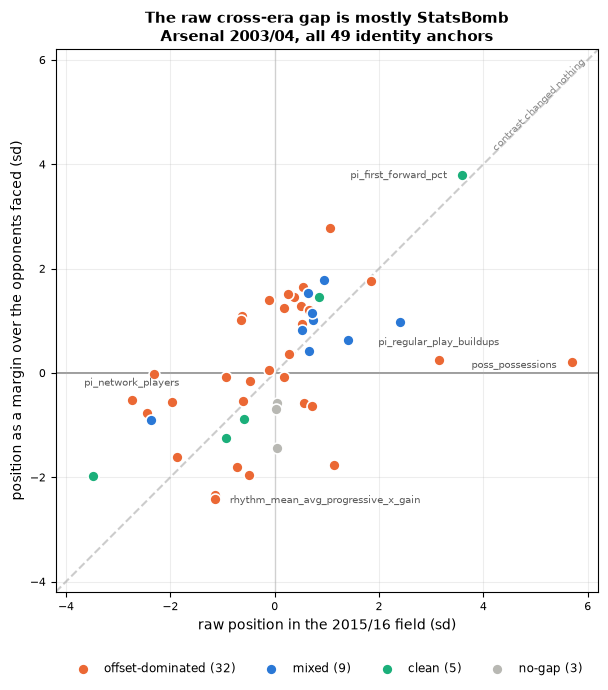

anchors that lost the most gap to the correction:
                                  raw_z  contrast_z           verdict  gap_lost
poss_possessions                   5.69        0.20  offset-dominated      5.49
pi_regular_play_buildups           3.14        0.24  offset-dominated      2.90
pi_early_central_involvement_pct  -2.31       -0.01  offset-dominated      2.30
pi_network_players                -2.74       -0.51  offset-dominated      2.23
rp6_mean_end_x                    -2.46       -0.76  offset-dominated      1.69
rp6_mean_start_x                  -3.49       -1.98             clean      1.52


In [5]:
VERDICT_COLOR = {"offset-dominated": "#eb6834", "mixed": "#2a78d6",
                 "clean": "#1baf7a", "no-gap": "#b8b8b3"}

fig, ax = plt.subplots(figsize=(8.5, 7))
lo, hi = -4.2, 6.2
ax.plot([lo, hi], [lo, hi], color="0.8", lw=1.5, ls="--", zorder=1)
ax.axhline(0, color="0.55", lw=1.2, zorder=1)
ax.axvline(0, color="0.85", lw=1, zorder=1)

for verdict, color in VERDICT_COLOR.items():
    sub = ledger[ledger["verdict"] == verdict]
    ax.scatter(sub["raw_z"], sub["contrast_z"], s=62, color=color, zorder=3,
               edgecolor="white", linewidth=1.2,
               label=f"{verdict} ({len(sub)})")

# Anchored by the room each point has, so nothing overflows the axes.
LABELS = {"poss_possessions": (-11, -4, "right"),
          "pi_regular_play_buildups": (0, 11, "center"),
          "pi_first_forward_pct": (-11, -2, "right"),
          "pi_network_players": (0, 10, "center"),
          "rhythm_mean_avg_progressive_x_gain": (11, -3, "left")}
for name, (dx, dy, ha) in LABELS.items():
    row = ledger.loc[name]
    ax.annotate(name, (row["raw_z"], row["contrast_z"]), textcoords="offset points",
                xytext=(dx, dy), ha=ha, fontsize=7.5, color="0.35")

ax.text(hi - 0.25, hi - 0.25, "contrast changed nothing", fontsize=7.5,
        color="0.55", ha="right", rotation=45, rotation_mode="anchor")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.set_xlabel("raw position in the 2015/16 field (sd)")
ax.set_ylabel("position as a margin over the opponents faced (sd)")
ax.set_title("The raw cross-era gap is mostly StatsBomb\n"
             f"Arsenal 2003/04, all {len(anchors)} identity anchors",
             fontweight="bold", fontsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=4,
          frameon=False, fontsize=8.5)
ax.grid(alpha=0.22); ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

moved = (ledger["raw_z"].abs() - ledger["contrast_z"].abs())
print("anchors that lost the most gap to the correction:")
print(pd.concat([ledger[["raw_z", "contrast_z", "verdict"]], moved.rename("gap_lost")],
                axis=1).sort_values("gap_lost", ascending=False).head(6).round(2).to_string())

## 4. Splitting the change: the league, or Arsenal?

With a per-match opponent on both sides, the cross-era change decomposes exactly:

```
(A_2016 - A_2004) = (O_2016 - O_2004) + (C_2016 - C_2004),   where C = A - O
```

Total change equals what the opponent pool did plus what Arsenal did relative to it. This
is algebra, not a model, so the residual is float noise.

The two terms must be read very differently, and this is the most important caveat in the
notebook. `team_moved` is drift-immune, being a difference of within-match margins.
`league_moved` is **exactly the negated drift estimate**, the same number the ledger
reports. Real league change and collection artifact are inseparable inside it at n = 2
seasons. A large `league_moved` is a reason to distrust the raw comparison, never evidence
that football changed.

Every term carries a 2,000-resample percentile interval, resampling whole matches so all
three terms come from the same resample. With 49 anchors tested at once, two or three clear
p < 0.05 by chance, so the headline claims go through a Benjamini-Hochberg correction.

In [6]:
evolution = decompose(old, CLUB, new, CLUB, anchors, scale=spread,
                      n_resamples=2000, seed=0)
evolution["team_sig"] = benjamini_hochberg(evolution["team_p"])
evolution["league_sig"] = benjamini_hochberg(evolution["league_p"])
evolution["verdict"] = ledger["verdict"]

residual = (evolution["total_change"] - evolution["league_moved"]
            - evolution["team_moved"]).abs().max()
print(f"decomposition residual: {residual:.2e}  (an identity, so this is float noise)")

print(f"\nuncorrected p < 0.05 on the Arsenal term: {(evolution['team_p'] < 0.05).sum()} "
      f"of {len(anchors)}   (expected by chance ~{0.05 * len(anchors):.1f})")
print(f"surviving Benjamini-Hochberg:                {evolution['team_sig'].sum()} "
      f"of {len(anchors)}")
print(f"of those, on the 15-feature spine:           "
      f"{evolution.loc[spine, 'team_sig'].sum()}")
print(f"\nfor contrast, the opponent-pool term clears BH on "
      f"{evolution['league_sig'].sum()} of {len(anchors)} anchors. That is a measure of "
      f"how far apart\nthe two collections sit, not evidence that football changed.")

print("\nwhere Arsenal genuinely moved relative to its contemporaries:")
sig = evolution[evolution["team_sig"]]
print(sig.reindex(sig["team_moved"].abs().sort_values(ascending=False).index)[
    ["total_change", "league_moved", "team_moved", "team_lo", "team_hi", "verdict"]
].round(2).to_string())

decomposition residual: 4.44e-16  (an identity, so this is float noise)

uncorrected p < 0.05 on the Arsenal term: 7 of 49   (expected by chance ~2.5)
surviving Benjamini-Hochberg:                4 of 49
of those, on the 15-feature spine:           0

for contrast, the opponent-pool term clears BH on 24 of 49 anchors. That is a measure of how far apart
the two collections sit, not evidence that football changed.

where Arsenal genuinely moved relative to its contemporaries:
                               total_change  league_moved  team_moved  team_lo  team_hi           verdict
poss_median_events_per_sec             1.59         -2.63        4.23     2.25     6.18            no-gap
poss_mean_start_x                      1.51         -1.71        3.22     1.16     5.33  offset-dominated
pi_pass_progression_share_pct         -0.31         -2.88        2.57     1.59     3.62  offset-dominated
carries_per100pass                     0.26          2.12       -1.86    -2.87    -0.83  offset-d

### Chart 2 — the spine, split in two

Grouped rather than stacked, because the two components regularly carry opposite signs and
a signed stack would read as cancellation rather than as two separate movements. The
diamond marks the total, which is their sum.

`pi_angle_entropy` is the case to look for. Phase 3b called it the single most stable
feature for both champions. Across the eras it shifts nearly two standard deviations, and
almost none of that is Arsenal.

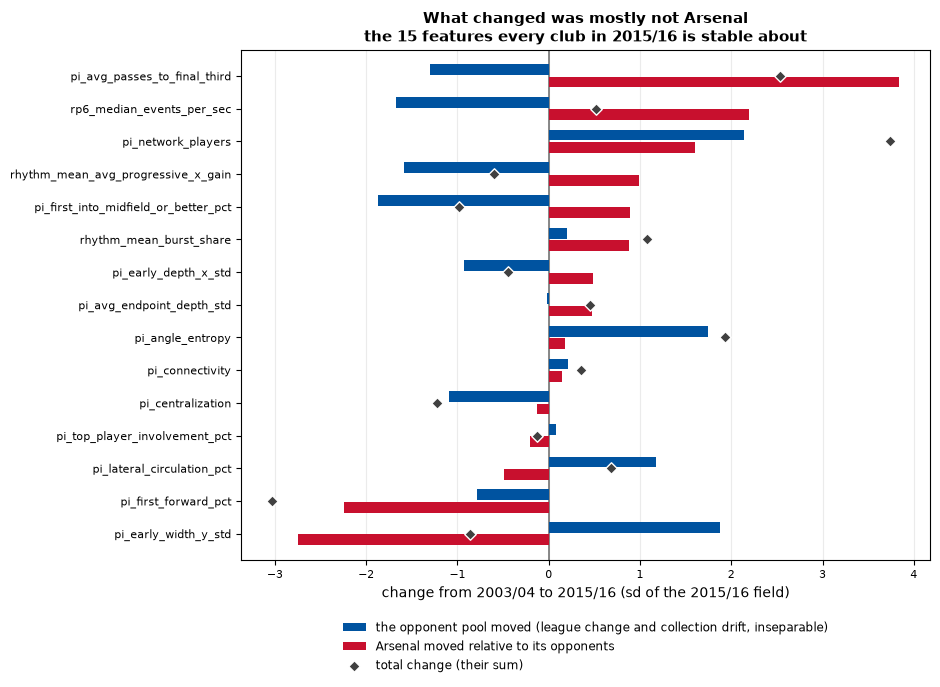

the spine, ordered by how far Arsenal moved against its peers:
                                      total_change  league_moved  team_moved  team_lo  team_hi  team_p  team_sig
pi_avg_passes_to_final_third                  2.53         -1.30        3.83     0.05     7.52    0.05     False
pi_early_width_y_std                         -0.87          1.88       -2.75    -4.74    -0.81    0.01     False
pi_first_forward_pct                         -3.03         -0.78       -2.24    -4.99     0.37    0.09     False
rp6_median_events_per_sec                     0.52         -1.67        2.19     0.00     4.42    0.05     False
pi_network_players                            3.74          2.14        1.60    -1.07     4.27    0.26     False
rhythm_mean_avg_progressive_x_gain           -0.60         -1.59        0.98     0.05     1.95    0.04     False
pi_first_into_midfield_or_better_pct         -0.98         -1.88        0.89    -1.48     3.27    0.47     False
rhythm_mean_burst_share          

In [7]:
LEAGUE_C, CLUB_C = "#0053a0", "#c8102e"

panel = evolution.loc[spine].sort_values("team_moved")
y = np.arange(len(panel)); h = 0.33   # a visible gap between the paired bars

fig, ax = plt.subplots(figsize=(9.5, 7))
ax.axvline(0, color="0.45", lw=1.2, zorder=2)
bars = [
    ax.barh(y + 0.19, panel["league_moved"], height=h, color=LEAGUE_C, zorder=3,
            label="the opponent pool moved (league change and collection drift, inseparable)"),
    ax.barh(y - 0.19, panel["team_moved"], height=h, color=CLUB_C, zorder=3,
            label="Arsenal moved relative to its opponents"),
    ax.scatter(panel["total_change"], y, marker="D", s=34, color="0.25", zorder=4,
               edgecolor="white", linewidth=1.0, label="total change (their sum)"),
]

ax.set_yticks(y); ax.set_yticklabels(panel.index, fontsize=8)
ax.set_ylim(-0.8, len(panel) - 0.2)
ax.set_xlabel("change from 2003/04 to 2015/16 (sd of the 2015/16 field)")
ax.set_title("What changed was mostly not Arsenal\n"
             f"the {len(spine)} features every club in 2015/16 is stable about",
             fontweight="bold", fontsize=11)
ax.legend(handles=bars, loc="upper center", bbox_to_anchor=(0.5, -0.10),
          ncol=1, frameon=False, fontsize=8.5)
ax.grid(axis="x", alpha=0.25); ax.tick_params(labelsize=8)
ax.xaxis.set_major_locator(MultipleLocator(1))
plt.tight_layout(); plt.show()

print("the spine, ordered by how far Arsenal moved against its peers:")
print(panel.reindex(panel["team_moved"].abs().sort_values(ascending=False).index)[
    ["total_change", "league_moved", "team_moved", "team_lo", "team_hi",
     "team_p", "team_sig"]].round(2).to_string())

## 5. Where Arsenal 2003/04 lands among the clubs of 2015/16

The contrast field holds all twenty 2015/16 clubs expressed the same way, as margins over
the opponents each actually faced. Arsenal 2003/04 can be placed in it. The question with
an answer worth checking: of those twenty clubs, which does the 2003/04 side most resemble?

In [8]:
margin_04 = team_contrast(old, CLUB, anchors)
placed = margin_field.place(margin_04)

gaps = np.sqrt(((margin_field.z - placed["z"]) ** 2).sum(axis=1)).sort_values()
print("Arsenal 2003/04's nearest clubs in the 2015/16 contrast field:")
print(gaps.head(5).round(2).to_string())

pairs = margin_field.distances.to_numpy()
off_diagonal = pairs[~np.eye(len(pairs), dtype=bool)]
print(f"\nfor scale, distances between the 2015/16 clubs themselves: "
      f"min {off_diagonal.min():.2f}, median {np.median(off_diagonal):.2f}, "
      f"max {off_diagonal.max():.2f}")

print(f"\nArsenal 2015/16's own nearest clubs:")
print(margin_field.neighbours(CLUB, 3).round(2).to_string())

Arsenal 2003/04's nearest clubs in the 2015/16 contrast field:
team
Arsenal              7.14
Chelsea              7.63
AFC Bournemouth      8.72
Tottenham Hotspur    9.09
Swansea City         9.23

for scale, distances between the 2015/16 clubs themselves: min 5.03, median 9.47, max 17.43

Arsenal 2015/16's own nearest clubs:
Chelsea              5.03
Swansea City         7.60
Tottenham Hotspur    7.82


## 6. Frozen artifacts

In [9]:
ledger_out = ledger.rename_axis("feature").reset_index()
ledger_out["in_spine"] = ledger_out["feature"].isin(spine)
ledger_out.to_csv(FEATURES_DIR / "phase3d_confound_ledger_2004.csv", index=False)

evolution_out = evolution.rename_axis("feature").reset_index()
evolution_out["in_spine"] = evolution_out["feature"].isin(spine)
evolution_out.to_csv(FEATURES_DIR / "phase3d_evolution_decomposition.csv", index=False)

print(f"wrote phase3d_confound_ledger_2004.csv      ({len(ledger_out)} anchors)")
print(f"wrote phase3d_evolution_decomposition.csv   ({len(evolution_out)} anchors)")

wrote phase3d_confound_ledger_2004.csv      (49 anchors)
wrote phase3d_evolution_decomposition.csv   (49 anchors)


## Summary — the Invincibles and the 2015/16 Arsenal, side by side

### The headline

Almost everything that separates Arsenal 2003/04 from Arsenal 2015/16 in the raw numbers is
not Arsenal. **32 of the 49 identity anchors carry more collection drift than cross-era
signal**, so a naive percentile comparison between the two seasons is mostly a report on how
StatsBomb segmented possessions in each collection pass.

Once the contrast removes that, the club's fingerprint turns out to be remarkably durable.
Only **4 of 49 anchors** show a change in Arsenal's margin over its opponents that survives a
multiple-comparison correction, and **none of the 15 spine features do**. Arsenal moved on
tempo and on where it started possessions. Its passing structure did not move at all.

### What the raw comparison would have told you, and why it is wrong

| anchor | raw z | drift share | verdict | contrast z |
|---|---|---|---|---|
| `poss_possessions` | +5.69 | 1.33 | offset-dominated | **+0.20** |
| `pi_regular_play_buildups` | +3.14 | 1.04 | offset-dominated | **+0.24** |
| `pi_network_players` | −2.74 | 0.78 | offset-dominated | **−0.51** |
| `rp6_mean_end_x` | −2.46 | 1.22 | offset-dominated | **−0.76** |
| `pi_first_forward_pct` | +3.60 | 0.22 | clean | **+3.79** |

The first four are the phase's cautionary tale. Read raw, they say the Invincibles ran a
vastly higher volume of possessions through a smaller passing network than any modern side.
Read as margins, they say almost nothing. Arsenal 2003/04 recorded 108.9 possessions per
match and the nineteen clubs it played recorded 108.0, while the 2015/16 league averaged
95.1. Both sides of every 2003/04 fixture were inflated together, which is the signature of
segmentation and not of football.

The last row is the control. `pi_first_forward_pct` carries a drift share of 0.22, and its
gap survives the correction intact, moving from +3.60 to +3.79. The method is not a
flattener. It removes what is shared and keeps what is not.

### Arsenal 2003/04, as a margin over the nineteen clubs it played

Percentiles are against the twenty clubs of 2015/16, each measured the same way.

**What the Invincibles did more than their opponents.** The first pass out of a possession
went forward at the **100th percentile** (74.1% against their opponents' 66.6%). They carried
at the **100th percentile** (78.3 carries per 100 passes against 68.7). They played in bursts
at the 90th, spread the early build wide at the 90th, circulated laterally at the 80th, and
connected more players at the 80th.

**What they did less.** Their possessions started deeper than their opponents' (10th
percentile), gained less ground per possession (**0th percentile**), varied their early depth
less (0th), progressed a smaller share of passes (0th), and reached midfield or better with
the first pass less often (10th).

Those two lists look contradictory until you put them together. The first pass went forward
but rarely cleared midfield, the possession started deep, ground was gained by carrying
rather than by passing, and the shape was wide and laterally connected. That is a side that
takes the ball deep, works it short and forward into feet, and advances by running with it
through a wide, well-connected structure. It is not a side that transits the pitch quickly.

### Arsenal 2015/16, the same measurements

**More than its opponents.** Burst share at the **100th percentile**, events per second at the
**100th**, first pass forward at the 95th, passes into the final third at the 95th, sustained
buildup tempo at the 95th, connectivity at the 85th.

**Less.** Early-depth variation at the 5th, ground gained per possession at the 5th,
top-player involvement at the 15th.

### What actually changed, with intervals

Four anchors clear Benjamini-Hochberg. All four describe the same shift.

| anchor | 2003/04 | 2015/16 | Arsenal moved (sd) | 95% interval |
|---|---|---|---|---|
| `poss_median_events_per_sec` | 30th pct | **100th** | +4.23 | [+2.25, +6.18] |
| `poss_mean_start_x` | 10th pct | 65th | +3.22 | [+1.16, +5.33] |
| `pi_pass_progression_share_pct` | 0th pct | 60th | +2.57 | [+1.59, +3.62] |
| `carries_per100pass` | 100th pct | 80th | −1.86 | [−2.87, −0.83] |

Read together: the 2015/16 side **started possessions higher up the pitch** (raw mean 48.0
against 44.8), **moved the ball faster**, **progressed a larger share of its passes**, and
**carried less**. The Invincibles advanced by running with the ball from deep. The 2015/16
team advanced by passing it from further forward.

### What did not change, which is the more interesting half

The passing machinery is the same club across twelve years. On the spine, the percentile of
Arsenal's margin barely moves:

| spine feature | 2003/04 | 2015/16 |
|---|---|---|
| `pi_centralization` | 30th | 30th |
| `pi_top_player_involvement_pct` | 15th | 15th |
| `pi_connectivity` | 80th | 85th |
| `pi_angle_entropy` | 20th | 40th |
| `pi_lateral_circulation_pct` | 80th | 75th |

Phase 3b singled out `pi_angle_entropy` as the lowest-variance feature for both champions and
called it a universal identity axis. This notebook tests that across eras and the answer
holds, but for a reason worth stating exactly. The feature moves **+1.93 sd** between the two
seasons, and the decomposition assigns **+1.75 of it to the opponent pool and +0.18 to
Arsenal**, with an interval of [−1.43, +1.84] that comfortably contains zero. Arsenal did not
change its passing-angle structure. Everything around it read differently.

The nearest-neighbour check makes the same point from outside the feature list. Placing
Arsenal 2003/04 among the twenty clubs of 2015/16 as margins, its closest club is **Arsenal
2015/16, at a distance of 7.14**, ahead of Chelsea at 7.63. Twelve years, a different squad,
and the club still lands nearest to itself. The margin over Chelsea is small enough that this
is a supporting result rather than a proof, and it should be read that way.

### What this notebook cannot claim

**That football changed.** The `league_moved` column is algebraically identical to the negated
drift estimate. Real league change and collection artifact are the same number inside it at
n = 2 seasons. 24 of its 49 entries clear Benjamini-Hochberg, and that is not evidence about
football. It is a measure of how far apart the two collections sit.

**That the four significant changes are precisely sized.** The intervals are wide because
each season supplies 38 paired matches. The `poss_mean_start_x` shift is somewhere between
+1.16 and +5.33 sd, which supports the direction and not the magnitude.

**That the contrast handles every kind of drift.** It cancels whatever a season adds equally
to both sides of a fixture. If a possession *means* something different in 2003 than in 2015,
rather than merely being counted differently, the contrast removes the level and leaves the
meaning. The offset-dominated anchors are where that risk is highest, so their corrected
values deserve more suspicion than the clean ones, not less.

### Hand-off to 3d-ii

The contrast field and the ledger both transfer. 3d-ii compares Arsenal 2003/04 against
Leicester 2015/16, where the decomposition does not apply because there is no shared before to
subtract. What carries over is the finding that a champion's margin over the teams it beat is
a measurable and durable object, which is exactly what the two title-winning seasons will be
compared as.